## Installation (execute only if running on a cloud platform!)¶

In [27]:
# -- Use the following line for google colab removing the hash at the beginning.
! pip install -q 'corner==2.2.2' 'bilby==2.2.2' 'astropy==6.0.1'

**Important**: With Google Colab, you may need to restart the runtime after running the cell above.

## Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
import corner

## Get the data

We first have to select the event. Let's pick GW150914!

In [2]:
event_label = 'GW190814'

# Direct download from LIGO DCC
!wget -O {event_label}_posterior_samples.h5 https://dcc.ligo.org/public/0168/P2000183/008/GW190814_posterior_samples.h5

posterior_file = f'./{event_label}_posterior_samples.h5'
print('Using file:', posterior_file)

--2025-11-06 14:07:18--  https://dcc.ligo.org/public/0168/P2000183/008/GW190814_posterior_samples.h5
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 484389803 (462M)
Saving to: ‘GW190814_posterior_samples.h5’

GW190814_posterior_ 100%[===================>] 461.95M  24.1MB/s    in 18s     

2025-11-06 14:07:36 (25.6 MB/s) - ‘GW190814_posterior_samples.h5’ saved [484389803/484389803]

Using file: ./GW190814_posterior_samples.h5


In [3]:
# Open the posterior file
posterior_file = f'./{event_label}_posterior_samples.h5'
posterior = h5py.File(posterior_file, 'r')

print("Top-level groups:", list(posterior.keys()))

Top-level groups: ['C01:IMRPhenomD', 'C01:IMRPhenomHM', 'C01:IMRPhenomNSBH', 'C01:IMRPhenomPv3HM', 'C01:SEOBNRv4HM_ROM', 'C01:SEOBNRv4PHM', 'C01:SEOBNRv4_ROM', 'C01:SEOBNRv4_ROM_NRTidalv2_NSBH', 'combined', 'history', 'version']


### Looking into the file structure

In [4]:
print('This file contains four datasets: ',posterior.keys())

This file contains four datasets:  <KeysViewHDF5 ['C01:IMRPhenomD', 'C01:IMRPhenomHM', 'C01:IMRPhenomNSBH', 'C01:IMRPhenomPv3HM', 'C01:SEOBNRv4HM_ROM', 'C01:SEOBNRv4PHM', 'C01:SEOBNRv4_ROM', 'C01:SEOBNRv4_ROM_NRTidalv2_NSBH', 'combined', 'history', 'version']>


In [6]:
for g in ['combined',
          'C01:IMRPhenomPv3HM',
          'C01:SEOBNRv4PHM',
          'C01:IMRPhenomD']:
    if g in posterior.keys():
        print(f"\nGroup: {g}")
        print(list(posterior[g].keys()))



Group: combined
['approximant', 'calibration_envelope', 'config_file', 'injection_data', 'meta_data', 'posterior_samples', 'priors', 'psds', 'version']

Group: C01:IMRPhenomPv3HM
['approximant', 'calibration_envelope', 'config_file', 'injection_data', 'meta_data', 'posterior_samples', 'priors', 'psds', 'version']

Group: C01:SEOBNRv4PHM
['approximant', 'calibration_envelope', 'config_file', 'injection_data', 'meta_data', 'posterior_samples', 'priors', 'psds', 'version']

Group: C01:IMRPhenomD
['approximant', 'calibration_envelope', 'config_file', 'injection_data', 'meta_data', 'posterior_samples', 'priors', 'psds', 'version']


In [7]:
# Use the combined mix (you can swap for a specific model if you want)
best_path = 'combined/posterior_samples'
dset = posterior[best_path]

print("Selected:", best_path)
print("Rows, Cols:", dset.shape, len(dset.dtype.names))
print("Columns (first 40):", list(dset.dtype.names)[:40])


Selected: combined/posterior_samples
Rows, Cols: (27736,) 157
Columns (first 40): ['recalib_L1_frequency_6', 'recalib_V1_phase_2', 'V1_matched_filter_abs_snr', 'recalib_H1_phase_2', 'recalib_V1_amplitude_0', 'log_likelihood', 'recalib_L1_phase_1', 'recalib_V1_phase_9', 'recalib_H1_frequency_7', 'recalib_L1_frequency_2', 'recalib_V1_amplitude_8', 'recalib_H1_amplitude_0', 'recalib_H1_frequency_2', 'recalib_L1_phase_5', 'spin_1y', 'V1_matched_filter_snr_angle', 'peak_luminosity', 'recalib_L1_frequency_0', 'final_spin', 'recalib_H1_frequency_5', 'V1_optimal_snr', 'recalib_L1_amplitude_2', 'psi', 'phi_2', 'chi_2_in_plane', 'recalib_V1_frequency_3', 'recalib_H1_frequency_9', 'recalib_V1_phase_0', 'recalib_H1_phase_8', 'recalib_H1_frequency_4', 'recalib_V1_amplitude_1', 'recalib_V1_phase_5', 'recalib_V1_phase_7', 'spin_1z', 'recalib_H1_phase_0', 'recalib_H1_amplitude_4', 'network_matched_filter_snr', 'mass_2', 'recalib_L1_amplitude_3', 'recalib_H1_phase_4']


In [8]:
import numpy as np, pandas as pd

samples = pd.DataFrame.from_records(np.array(dset))

# Map GWTC-2 style names to the ones your original notebook expected
rename_map = {}
if "mass_1" in samples.columns and "m1_detector_frame_Msun" not in samples.columns:
    rename_map["mass_1"] = "m1_detector_frame_Msun"
if "mass_2" in samples.columns and "m2_detector_frame_Msun" not in samples.columns:
    rename_map["mass_2"] = "m2_detector_frame_Msun"
if "luminosity_distance" in samples.columns and "luminosity_distance_Mpc" not in samples.columns:
    rename_map["luminosity_distance"] = "luminosity_distance_Mpc"

if rename_map:
    samples = samples.rename(columns=rename_map)
    print("Applied renames:", rename_map)

print("Available columns now (first 40):")
print(list(samples.columns)[:40])

samples.head()


Applied renames: {'mass_1': 'm1_detector_frame_Msun', 'mass_2': 'm2_detector_frame_Msun', 'luminosity_distance': 'luminosity_distance_Mpc'}
Available columns now (first 40):
['recalib_L1_frequency_6', 'recalib_V1_phase_2', 'V1_matched_filter_abs_snr', 'recalib_H1_phase_2', 'recalib_V1_amplitude_0', 'log_likelihood', 'recalib_L1_phase_1', 'recalib_V1_phase_9', 'recalib_H1_frequency_7', 'recalib_L1_frequency_2', 'recalib_V1_amplitude_8', 'recalib_H1_amplitude_0', 'recalib_H1_frequency_2', 'recalib_L1_phase_5', 'spin_1y', 'V1_matched_filter_snr_angle', 'peak_luminosity', 'recalib_L1_frequency_0', 'final_spin', 'recalib_H1_frequency_5', 'V1_optimal_snr', 'recalib_L1_amplitude_2', 'psi', 'phi_2', 'chi_2_in_plane', 'recalib_V1_frequency_3', 'recalib_H1_frequency_9', 'recalib_V1_phase_0', 'recalib_H1_phase_8', 'recalib_H1_frequency_4', 'recalib_V1_amplitude_1', 'recalib_V1_phase_5', 'recalib_V1_phase_7', 'spin_1z', 'recalib_H1_phase_0', 'recalib_H1_amplitude_4', 'network_matched_filter_snr', 

,recalib_L1_frequency_6,recalib_V1_phase_2,V1_matched_filter_abs_snr,recalib_H1_phase_2,recalib_V1_amplitude_0,log_likelihood,recalib_L1_phase_1,recalib_V1_phase_9,recalib_H1_frequency_7,recalib_L1_frequency_2,...,recalib_H1_amplitude_1,recalib_L1_phase_4,V1_matched_filter_snr,redshift,mass_1_source,mass_2_source,total_mass_source,chirp_mass_source,final_mass_source,radiated_energy
0,501.092863,0.054505,4.031903,0.011393,0.013002,298.810474,0.017793,-0.079288,732.126826,76.686734,...,-0.000071,-0.010873,4.031744,0.045366,23.464227,2.594217,26.058444,6.129963,25.817193,0.241251
1,501.092863,0.049019,4.078679,0.003419,0.026980,297.717159,-0.012247,0.042330,732.126826,76.686734,...,-0.013924,0.002995,4.045235,0.049479,23.230846,2.594176,25.825022,6.104225,25.584834,0.240188
2,501.092863,-0.005722,3.548885,-0.001196,-0.052455,296.275702,-0.057961,0.117502,732.126826,76.686734,...,0.004049,-0.007287,3.542621,0.052367,23.105215,2.592148,25.697364,6.087574,25.456931,0.240433
3,501.092863,0.017505,4.393948,0.006857,-0.039296,300.878832,-0.071081,-0.107651,732.126826,76.686734,...,-0.033871,0.002897,4.217755,0.060808,22.854076,2.573592,25.427668,6.034492,25.189582,0.238086
4,501.092863,0.044846,4.248864,-0.008504,-0.033981,294.420624,-0.044678,0.166018,732.126826,76.686734,...,0.001610,-0.011321,4.241640,0.037232,23.870950,2.597200,26.468150,6.178461,26.226191,0.241959


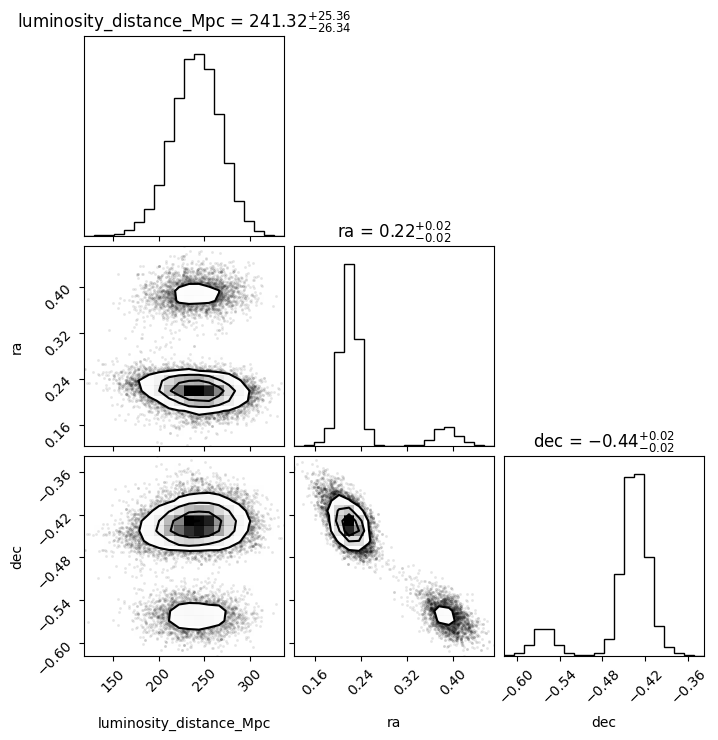

In [16]:
import corner, matplotlib.pyplot as plt

cols = [c for c in [
    "luminosity_distance_Mpc","ra","dec"
] if c in samples.columns]

if len(cols) >= 2:
    fig = corner.corner(samples[cols].values, labels=cols, show_titles=True)
    plt.show()
else:
    print("Not enough overlapping parameters for a corner plot. Found:", cols)


This data file contains several datasets, two using separate models for the gravitational waveform (`IMRPhenomPv2` and `SEOBNRv3` respectively, see the [paper](https://arxiv.org/abs/1811.12907) for more details).

It also contains a joint dataset, combining equal numbers of samples from each individual model, these datasets are what is shown in the [paper](https://arxiv.org/abs/1811.12907).

Finally, there is a dataset containing samples drawn from the prior used for the analyses.

In [11]:
m1 = samples.get("m1_detector_frame_Msun")
m2 = samples.get("m2_detector_frame_Msun")

if m1 is not None and m2 is not None:
    mchirp = ((m1 * m2)**(3.0/5.0)) / ((m1 + m2)**(1.0/5.0))
    def p(x): return np.percentile(mchirp, [5, 50, 95])
    lo, med, hi = p(mchirp)
    print(f"Chirp mass (detector frame), median = {med:.3f} Msun; 90% CI = [{lo:.3f}, {hi:.3f}] Msun")
else:
    print("m1/m2 missing — skipping chirp mass.")


Chirp mass (detector frame), median = 6.413 Msun; 90% CI = [6.393, 6.429] Msun


Here are some brief descriptions of these parameters and their units:

 * `luminosity_distance_Mpc`: luminosity distance [Mpc]

 * `m1_detector_frame_Msun`: primary (larger) black hole mass (detector frame) [solar mass]

 * `m2_detector_frame_Msun`: secondary (smaller) black hole mass (detector frame) [solar mass]

 * `right_ascension`, `declination`: right ascension and declination of the source [rad].

 * `costheta_jn`: cosine of the angle between line of sight and total angular momentum vector of the system.

 * `spin1`, `costilt1`: primary (larger) black hole spin magnitude (dimensionless) and cosine of the zenith angle between the spin and the orbital angular momentum vector of the system.

 * `spin2`, `costilt2`: secondary (smaller) black hole spin magnitude (dimensionless) and cosine of the zenith angle between the spin and the orbital angular momentum vector of the system.

A convenient (and pretty) way to load up this array of samples is to use [pandas](https://pandas.pydata.org/):

In [14]:
import corner, matplotlib.pyplot as plt

cols = [c for c in [
    "m1_detector_frame_Msun","m2_detector_frame_Msun",
] if c in samples.columns]

if len(cols) >= 2:
    fig = corner.corner(
        samples[cols].values,
        labels=[r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$",
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".2f",
        title_kwargs={"fontsize":10},
        color="royalblue",
        hist_kwargs={"density":True,"alpha":0.75},
        label_kwargs={"fontsize":11},
        max_n_ticks=4,
        smooth=1.2,
        plot_datapoints=False,
        fill_contours=True,
        plot_density=True,
        contour_kwargs={"colors":["royalblue"]},
        contourf_kwargs={"cmap":"Blues"},
    )
    fig.suptitle("GW190814 Posterior Samples", fontsize=14, y=1.02)
    plt.show()
else:
    print("Not enough overlapping parameters for a corner plot.")


SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' on line 10 (ipython-input-3498490464.py, line 25)

And we can plot the marginalised probability density functions:

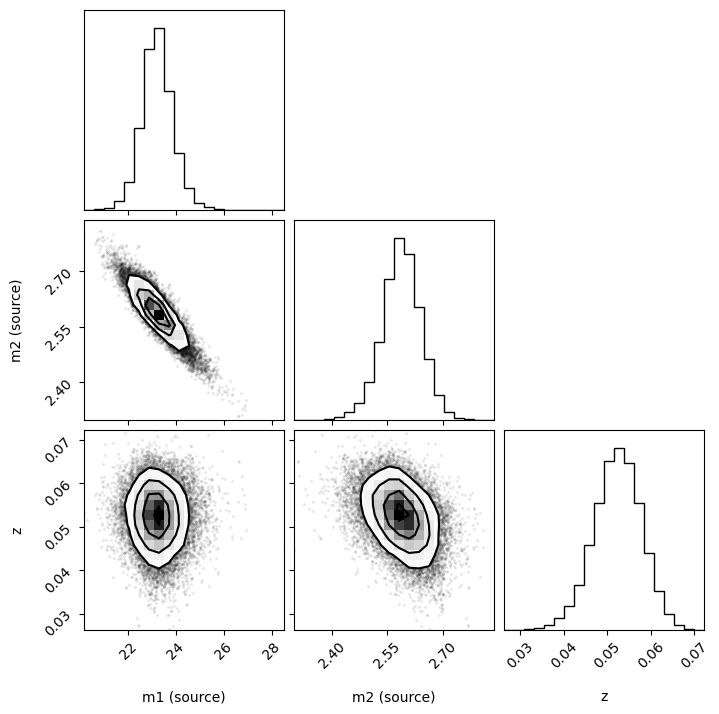

In [15]:
corner.corner(samples[['m1_source_frame_Msun','m2_source_frame_Msun','redshift']].values,labels=['m1 (source)',
                                                                                          'm2 (source)',
                                                                                          'z']);

## Calculating credible intervals
Let's see how we can use Bilby to calculate summary statistics for the posterior like the median and 90% credible level.

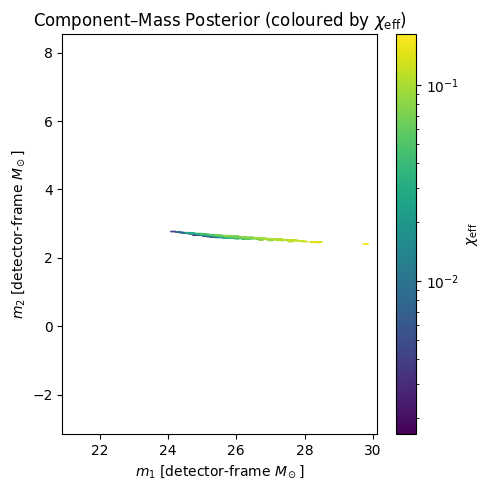

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
hb = plt.hexbin(
    samples["m1_detector_frame_Msun"],
    samples["m2_detector_frame_Msun"],
    C=samples.get("chi_eff", None),
    gridsize=60, bins="log"  # no explicit cmap per your style rules
)

plt.xlabel(r"$m_1$ [detector-frame $M_\odot$]")
plt.ylabel(r"$m_2$ [detector-frame $M_\odot$]")
plt.title(r"Component–Mass Posterior (coloured by $\chi_{\mathrm{eff}}$)")
cb = plt.colorbar()
cb.set_label(r"$\chi_{\mathrm{eff}}$")

plt.axis("equal")
plt.tight_layout()
plt.show()


## Challenge question
Calculate the posterior for the effective spin, which is the mass-weighted component of the binary spin aligned to the orbital angular momentum. It is given by Eqn. 3 of https://journals.aps.org/prx/pdf/10.1103/PhysRevX.9.011001. The z-component of each component spin is defined as $\chi_{1z} = \chi_{1}\cos{\theta_{1}}$. Then initialize a `SamplesSummary` object for the chi_eff posterior and calculate the mean and the lower and upper absolute credible interval.

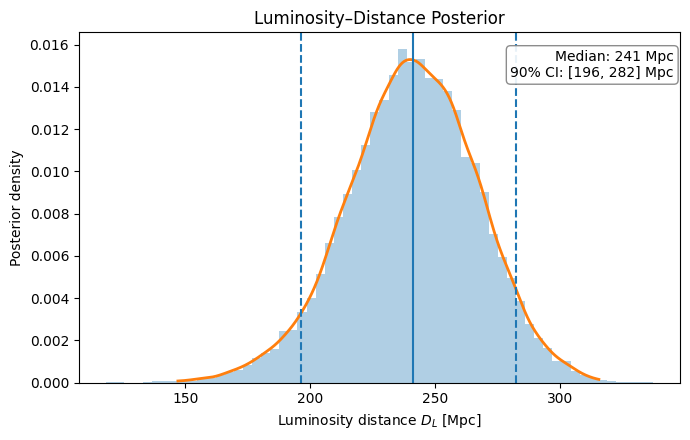

Saved: luminosity_distance_posterior.png


In [20]:
# Luminosity-distance posterior: histogram + KDE + annotated credible interval
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- pull distances in Mpc (GWTC-2 may use 'luminosity_distance')
col = "luminosity_distance_Mpc" if "luminosity_distance_Mpc" in samples.columns else "luminosity_distance"
if col not in samples.columns:
    raise KeyError("No luminosity distance column found (looked for 'luminosity_distance_Mpc' and 'luminosity_distance').")

d = np.asarray(samples[col], dtype=float)
d = d[np.isfinite(d)]

# --- summary stats
lo, med, hi = np.percentile(d, [5, 50, 95])

# --- kde
kde = gaussian_kde(d)
xmin, xmax = np.percentile(d, [0.1, 99.9])
x = np.linspace(max(1e-6, xmin), xmax, 800)
y = kde(x)

# --- plot
plt.figure(figsize=(7,4.5))
# histogram (density) – default color, no seaborn
plt.hist(d, bins=60, density=True, alpha=0.35)
# kde line
plt.plot(x, y, linewidth=2)

# vertical lines for 5%, 50%, 95%
for val, ls in [(lo, "--"), (med, "-"), (hi, "--")]:
    plt.axvline(val, linestyle=ls, linewidth=1.5)

# labels & title (use raw strings to avoid LaTeX escapes issues)
plt.xlabel(r"Luminosity distance $D_L$ [Mpc]")
plt.ylabel("Posterior density")
plt.title(r"Luminosity–Distance Posterior")

# annotation box
txt = (rf"Median: {med:.0f} Mpc" "\n"
       rf"90% CI: [{lo:.0f}, {hi:.0f}] Mpc")
plt.text(0.99, 0.95, txt, ha="right", va="top", transform=plt.gca().transAxes,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.5", alpha=0.9), fontsize=10)

plt.tight_layout()
plt.savefig("luminosity_distance_posterior.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: luminosity_distance_posterior.png")


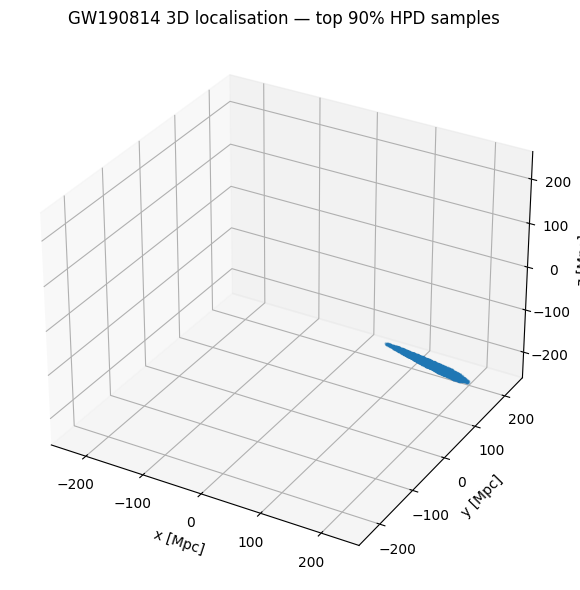

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # not used here, but for Option B

# 1) Get columns (GWTC-2 names already harmonized earlier)
ra = samples["ra"].to_numpy()          # radians
dec = samples["dec"].to_numpy()        # radians
dist = samples["luminosity_distance_Mpc"].to_numpy()  # Mpc

# 2) Convert to Cartesian (Mpc)
x = dist * np.cos(dec) * np.cos(ra)
y = dist * np.cos(dec) * np.sin(ra)
z = dist * np.sin(dec)
pts = np.vstack([x, y, z])

# 3) 3D KDE on the samples to approximate HPD
kde = gaussian_kde(pts)
dens = kde(pts)  # density at each sample

# 4) Keep the top 90% probability mass (approx via density ranking)
idx = np.argsort(dens)[::-1]        # high to low density
n90 = int(0.90 * len(dens))
sel = idx[:n90]

# 5) Plot a translucent point cloud
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[sel], y[sel], z[sel], s=1, alpha=0.15)  # no explicit color, small points

ax.set_xlabel(r"x [Mpc]")
ax.set_ylabel(r"y [Mpc]")
ax.set_zlabel(r"z [Mpc]")
ax.set_title(r"GW190814 3D localisation — top 90% HPD samples")
lim = np.percentile(np.abs(np.concatenate([x[sel], y[sel], z[sel]])), 99)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
plt.tight_layout()
plt.show()


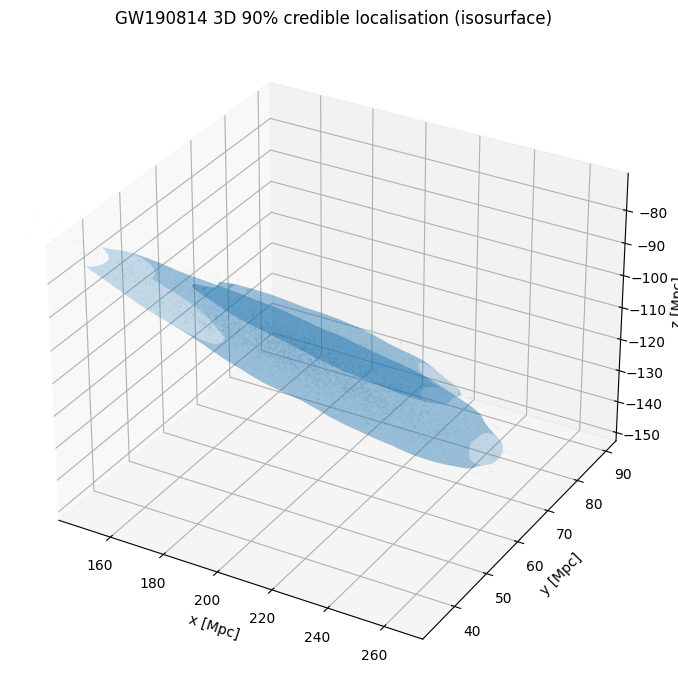

In [22]:
# !pip install scikit-image  # if needed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1) Cartesian samples (reuse x,y,z from Option A)
pts = np.vstack([x, y, z])

# 2) Fit KDE
kde = gaussian_kde(pts)

# 3) Build a regular 3-D grid over a quantile box
qmin, qmax = 1.0, 99.0
xmin, xmax = np.percentile(x, [qmin, qmax])
ymin, ymax = np.percentile(y, [qmin, qmax])
zmin, zmax = np.percentile(z, [qmin, qmax])

# Grid resolution — increase for smoother surface (costly!)
nx = ny = nz = 60
gx = np.linspace(xmin, xmax, nx)
gy = np.linspace(ymin, ymax, ny)
gz = np.linspace(zmin, zmax, nz)
X, Y, Z = np.meshgrid(gx, gy, gz, indexing="ij")
grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])

# 4) Evaluate KDE on the grid (density field)
pdf = kde(grid).reshape((nx, ny, nz))

# 5) Find density threshold that encloses ~90% probability (HPD)
# Sort voxels by density, integrate until 90%
flat = pdf.ravel()
order = np.argsort(flat)[::-1]
cdf = np.cumsum(flat[order])
cdf /= cdf[-1]
thr = flat[order][np.searchsorted(cdf, 0.90)]  # 90% HPD density level

# 6) Extract isosurface at that density
verts, faces, _, _ = measure.marching_cubes(pdf, level=thr)  # iso in index space

# 7) Map index space -> physical coordinates (Mpc)
sx = (xmax - xmin) / (nx - 1); sy = (ymax - ymin) / (ny - 1); sz = (zmax - zmin) / (nz - 1)
verts_phys = np.column_stack([
    xmin + verts[:, 0]*sx,
    ymin + verts[:, 1]*sy,
    zmin + verts[:, 2]*sz
])

# 8) Plot the 3D isosurface
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

mesh = Poly3DCollection(verts_phys[faces], alpha=0.25)  # translucent; default color
mesh.set_edgecolor('none')
ax.add_collection3d(mesh)

# Optional: overlay a faint subset of points to show sample distribution
sub = np.random.choice(len(x), size=min(5000, len(x)), replace=False)
ax.scatter(x[sub], y[sub], z[sub], s=0.2, alpha=0.05)

ax.set_xlabel(r"x [Mpc]"); ax.set_ylabel(r"y [Mpc]"); ax.set_zlabel(r"z [Mpc]")
ax.set_title(r"GW190814 3D 90% credible localisation (isosurface)")
ax.auto_scale_xyz([xmin, xmax], [ymin, ymax], [zmin, zmax])
plt.tight_layout()
plt.show()


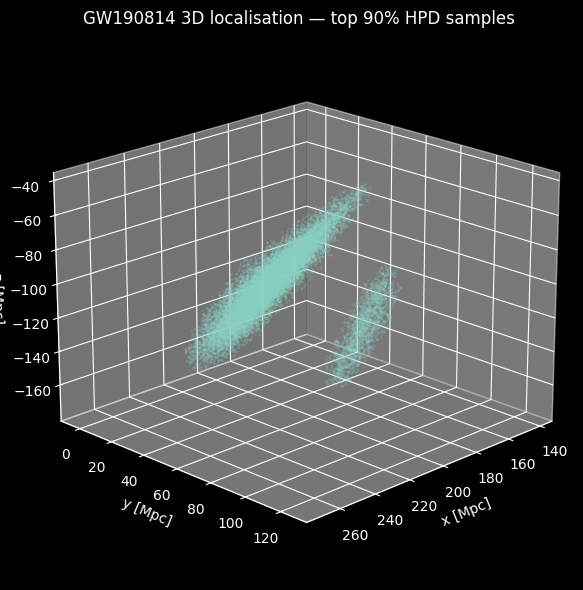

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# reuse x, y, z, sel from before (HPD-selected points)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[sel], y[sel], z[sel], s=1, alpha=0.15)

ax.set_xlabel(r"x [Mpc]")
ax.set_ylabel(r"y [Mpc]")
ax.set_zlabel(r"z [Mpc]")
ax.set_title(r"GW190814 3D localisation — top 90% HPD samples")

# --- Equalize the 3D aspect ratio ---
def set_axes_equal(ax):
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    spans = limits[:,1] - limits[:,0]
    centers = np.mean(limits, axis=1)
    radius = 0.5 * max(spans)
    ax.set_xlim3d([centers[0]-radius, centers[0]+radius])
    ax.set_ylim3d([centers[1]-radius, centers[1]+radius])
    ax.set_zlim3d([centers[2]-radius, centers[2]+radius])

set_axes_equal(ax)

# --- Adjust viewpoint ---
ax.view_init(elev=20, azim=45)  # play with angles
plt.tight_layout()
plt.show()


In [24]:
plt.style.use("dark_background")
ax.scatter(x[sel], y[sel], z[sel], s=1, alpha=0.1)
ax.set_facecolor("black")
ax.grid(False)


/tmp/ipython-input-1966471028.py:31: MatplotlibDeprecationWarning: The w_xaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use xaxis instead.
  for spine in ax.w_xaxis.get_ticklines()+ax.w_yaxis.get_ticklines()+ax.w_zaxis.get_ticklines(): spine.set_color("white")
/tmp/ipython-input-1966471028.py:31: MatplotlibDeprecationWarning: The w_yaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use yaxis instead.
  for spine in ax.w_xaxis.get_ticklines()+ax.w_yaxis.get_ticklines()+ax.w_zaxis.get_ticklines(): spine.set_color("white")
/tmp/ipython-input-1966471028.py:31: MatplotlibDeprecationWarning: The w_zaxis attribute was deprecated in Matplotlib 3.1 and will be removed in 3.8. Use zaxis instead.
  for spine in ax.w_xaxis.get_ticklines()+ax.w_yaxis.get_ticklines()+ax.w_zaxis.get_ticklines(): spine.set_color("white")
/tmp/ipython-input-1966471028.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large eno

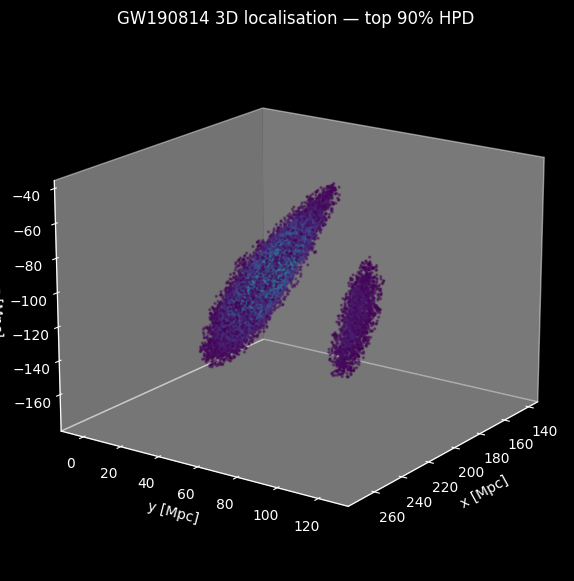

In [26]:
# --- assumes you already have x, y, z and sel (top-90% HPD indices) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

pts = np.vstack([x, y, z])
dens = gaussian_kde(pts)(pts)          # density at each sample
d90  = dens[sel]                        # HPD subset densities
c    = (d90 - d90.min())/(d90.max()-d90.min() + 1e-9)  # 0..1

fig = plt.figure(figsize=(7,7))
ax  = fig.add_subplot(111, projection="3d")
fig.patch.set_facecolor("black"); ax.set_facecolor("black")
ax.grid(False)

# layered “glow” (draw big faint points, then smaller brighter on top)
ax.scatter(x[sel], y[sel], z[sel], s=5,  alpha=0.06, c=c, cmap="viridis")
ax.scatter(x[sel], y[sel], z[sel], s=1,  alpha=0.45, c=c, cmap="viridis")

ax.set_xlabel(r"x [Mpc]", color="white"); ax.set_ylabel(r"y [Mpc]", color="white"); ax.set_zlabel(r"z [Mpc]", color="white")
ax.set_title(r"GW190814 3D localisation — top 90% HPD", color="white")

# equal aspect helper
def set_axes_equal(ax):
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    spans  = limits[:,1]-limits[:,0];  center = limits.mean(axis=1)
    r = 0.5*max(spans); ax.set_xlim(center[0]-r, center[0]+r); ax.set_ylim(center[1]-r, center[1]+r); ax.set_zlim(center[2]-r, center[2]+r)

set_axes_equal(ax)
ax.view_init(elev=18, azim=35)
for spine in ax.w_xaxis.get_ticklines()+ax.w_yaxis.get_ticklines()+ax.w_zaxis.get_ticklines(): spine.set_color("white")
for lab in ax.get_xticklabels()+ax.get_yticklabels()+ax.get_zticklabels(): lab.set_color("white")

plt.tight_layout()
plt.savefig("GW190814_3D_neon.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()


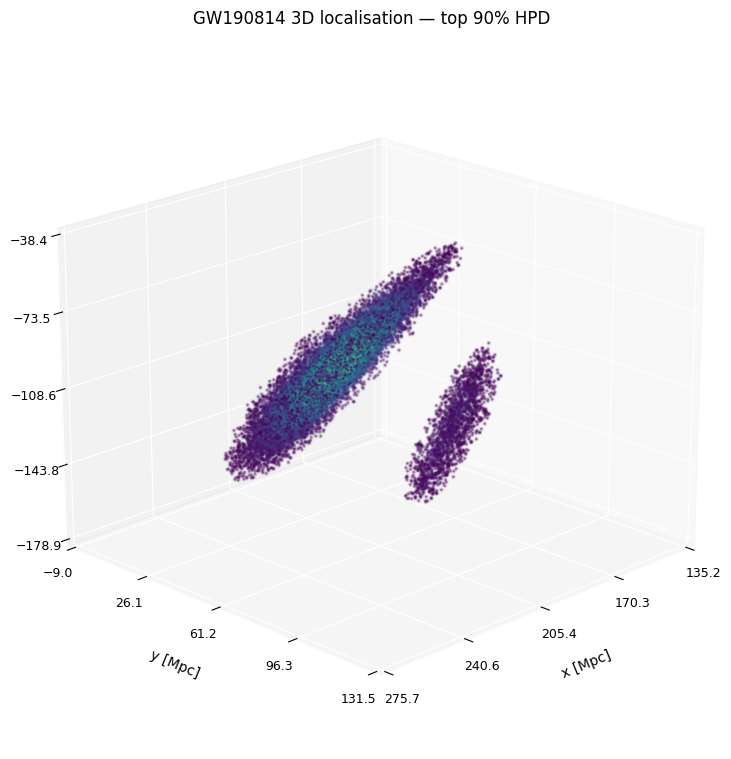

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- helper for equal aspect ---
def set_axes_equal(ax):
    """Equal aspect ratio for 3D plots."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    spans  = limits[:, 1] - limits[:, 0]
    center = limits.mean(axis=1)
    r = 0.5 * max(spans)
    ax.set_xlim(center[0] - r, center[0] + r)
    ax.set_ylim(center[1] - r, center[1] + r)
    ax.set_zlim(center[2] - r, center[2] + r)

# --- density colour grading (optional) ---
pts  = np.vstack([x, y, z])
dens = gaussian_kde(pts)(pts)
d90  = dens[sel]
c    = (d90 - d90.min()) / (d90.max() - d90.min() + 1e-12)

# --- figure setup ---
fig = plt.figure(figsize=(7,7))
fig.patch.set_facecolor("white")
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("white")
ax.grid(True, color="0.9")

# --- HPD cloud ---
ax.scatter(x[sel], y[sel], z[sel],
           s=8, alpha=0.07, c=c, cmap="viridis")
ax.scatter(x[sel], y[sel], z[sel],
           s=1.2, alpha=0.35, c=c, cmap="viridis")

# --- labels and title ---
ax.set_xlabel(r"x [Mpc]", color="black", labelpad=12)
ax.set_ylabel(r"y [Mpc]", color="black", labelpad=12)
ax.set_zlabel(r"z [Mpc]", color="black", labelpad=12)
ax.set_title(r"GW190814 3D localisation — top 90% HPD", color="black", pad=18)

# --- equal aspect and preferred orientation ---
set_axes_equal(ax)
ax.view_init(elev=20, azim=45)

# --- force numeric ticks back on ---
# (Manually choose a sensible tick interval based on the data range)
xr, yr, zr = ax.get_xlim(), ax.get_ylim(), ax.get_zlim()
ax.set_xticks(np.linspace(xr[0], xr[1], 5))
ax.set_yticks(np.linspace(yr[0], yr[1], 5))
ax.set_zticks(np.linspace(zr[0], zr[1], 5))

# Make tick labels visible in black
ax.tick_params(colors="black", labelsize=9)

plt.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)
plt.savefig("GW190814_3D_HPD_white_ticks.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

